In [1]:
!pip install --upgrade summa
!pip install --upgrade nltk #3.9.1

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'summa' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'summa'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for summa: filename=summa-1.2.0-py3-none-any.whl size=54441 sha256=f906c0f18e9240bd2f400753129d2adbf7afaa28da89b5b3022ecf08733f5223
  Stored in directory: /home/jovyan/.cache/pip/wheels/70/26/84/58df5a55ebde6fd802666b6ac0b86909ecd018a2702b89d13c
Successfully built summa
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nltk]1/2 [n

### 라이브러리 버전 확인

In [2]:
from importlib.metadata import version
import nltk
import torch
import summa
import pandas as pd

print(nltk.__version__)
print(torch.__version__)
print(pd.__version__)
print(version('summa'))

3.9.4
2.7.1+cu118
2.3.0
1.2.0


### 1. 데이터 수집하기

In [3]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

In [4]:
data.sample(10)

,headlines,text
84749,"Shikhar, Rohit, Rahane have family lunch en ro...","Cricketers Shikhar Dhawan, Ajinkya Rahane and ..."
253,This is the India team I fantasised as a playe...,"Speaking about the current Indian team, former..."
18692,"India's ties with Iran, Russia not main focus:...",US Secretary of State Mike Pompeo has said Ind...
81715,Younis to donate Ã¢ÂÂ¹61 lakh cash reward giv...,Cricketer Younis Khan has announced he will do...
9052,Walmart increases its 77% stake in Flipkart to...,"Walmart, which bought a 77% stake in Flipkart ..."
34238,"Veg diet healthy, non-veg unhealthy: Health Mi...",The Health Ministry had recently posted an ima...
28745,CID still probing 2009 murder plot complaint b...,The Maharashtra CID is still investigating a c...
79201,HC to hear plea against Madhur by Sanjay Gandh...,The Bombay HC is set to hear the plea asking f...
6448,Sara is a way better actor than I was: Saif Al...,Praising his daughter Sara Ali Khan's performa...
20041,India stands shoulder to shoulder with Kerala:...,Paying condolences to families of victims of K...


### 2. 데이터 전처리 하기

In [6]:
# 2. 데이터 전처리 (추상적 요약)

import nltk
import re
import numpy as np
from bs4 import BeautifulSoup
from nltk.corpus import stopwords

nltk.download('stopwords')  # 영어 불용어 사전 다운로드 (the, a, is 등 179개 단어 목록)

# ----------------------------------------------------------------
# 약어 정규화 사전
# 영어에서 축약형(contractions)은 같은 의미지만 다른 표현이므로
# 하나의 형태로 통일해서 단어장 크기를 줄이고 학습 효율을 높임
# 예) "isn't" → "is not", "won't" → "will not"
# ----------------------------------------------------------------
# 약어 정규화 사전
# 축약형을 완전한 형태로 통일해서 단어장 크기를 줄이고 학습 효율을 높임
contractions = {
    "ain't": "is not",
    "aren't": "are not",
    "can't": "cannot",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he's": "he is",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it's": "it is",
    "she's": "she is",
    "that's": "that is",
    "there's": "there is",
    "they're": "they are",
    "they've": "they have",
    "wasn't": "was not",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what's": "what is",
    "who's": "who is",
    "won't": "will not",
    "wouldn't": "would not",
    "you're": "you are",
    "you've": "you have"
}

print(f"약어 정규화 사전 크기: {len(contractions)}개")

약어 정규화 사전 크기: 30개


[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
# 전처리 함수 정의
# remove_stopwords=True  → 본문(text)용: 불용어 제거
# remove_stopwords=False → 요약(headlines)용: 불용어 유지
#
# [핵심 설계 결정] 요약문에 불용어를 유지하는 이유:
# headlines는 이미 짧은 문장(평균 10단어 내외)이므로
# 불용어까지 제거하면 의미가 손상될 수 있음
# 예) "the government will not raise taxes"
#      → 불용어 제거 시: "government raise taxes" (will not 의미 소실)
#      → 불용어 유지 시: "government will not raise taxes" (의미 보존)
# ----------------------------------------------------------------
def preprocess_sentence(sentence, remove_stopwords=True):

    # 1단계: 소문자 변환
    # 대소문자가 다른 같은 단어를 동일하게 처리
    sentence = sentence.lower()

    # 2단계: HTML 태그 제거
    # 뉴스 기사에는 <br>, <p>, <a href=...> 같은 HTML 태그가 포함될 수 있음
    # BeautifulSoup으로 태그를 파싱하고 순수 텍스트만 추출
    # html.parser: 파이썬 내장 파서 (lxml보다 느리지만 별도 설치 불필요)
    sentence = BeautifulSoup(sentence, "html.parser").text

    # 3단계: 괄호로 묶인 내용 제거
    # "(AP)", "(Reuters)", "(2024)" 같은 부가 정보 제거
    # 정규식 r'\([^)]*\)' = '(' 로 시작하고 ')' 로 끝나는 모든 문자열
    sentence = re.sub(r'\([^)]*\)', '', sentence)

    # 4단계: 쌍따옴표 제거
    # "he said" 처럼 인용구에 사용된 따옴표 제거
    sentence = re.sub('"', '', sentence)

    # 5단계: 약어 정규화
    # contractions 사전을 참조해서 축약형을 완전한 형태로 변환
    # 예) "won't" → "will not"
    # dict.get(key, default): 사전에 없으면 원래 단어 그대로 유지
    sentence = ' '.join([contractions.get(t, t) for t in sentence.split()])

    # 6단계: 소유격 제거
    # "Obama's" → "Obama", "company's" → "company"
    # \b: 단어 경계 (뒤에 다른 문자가 없을 때만 제거)
    sentence = re.sub(r"'s\b", "", sentence)

    # 7단계: 영문자 외 문자 제거
    # 숫자, 특수문자, 한자 등을 공백으로 치환
    # 영어 뉴스 요약 모델이므로 영문자만 남김
    sentence = re.sub(r"[^a-zA-Z]", " ", sentence)

    # 8단계: 다중 공백 정리
    # 앞 단계들을 거치면서 생긴 여러 개의 연속 공백을 하나로 합침
    sentence = re.sub(r'\s+', ' ', sentence).strip()

    # 9단계: 불용어 제거 (본문만 적용)
    if remove_stopwords:
        # 불용어 목록에 없고, 길이가 2자 이상인 단어만 남김
        # 1글자 단어(a, I 등)도 함께 제거
        tokens = ' '.join(
            word for word in sentence.split()
            if word not in stopwords.words('english') and len(word) > 1
        )
    else:
        # 요약문: 불용어는 유지하되 1글자 단어만 제거
        tokens = ' '.join(
            word for word in sentence.split()
            if len(word) > 1
        )

    return tokens

print('preprocess_sentence 함수 정의 완료')

preprocess_sentence 함수 정의 완료


In [8]:
from tqdm import tqdm  # 진행률 표시 라이브러리

# ----------------------------------------------------------------
# 데이터 준비: 필요한 컬럼만 선택
# headlines: 뉴스 요약문 (디코더 타겟)
# text     : 뉴스 본문   (인코더 입력)
# ----------------------------------------------------------------
data = data[['headlines', 'text']]

# NULL 값 제거: 본문이나 요약이 비어있는 샘플은 학습에 사용 불가
data = data.dropna()

# 중복 제거: 동일한 본문이 여러 번 등장하는 경우 하나만 남김
data = data.drop_duplicates(subset=['text'])

print('전처리 전 샘플 수:', len(data))

전처리 전 샘플 수: 98360


In [9]:
# ----------------------------------------------------------------
# 전처리 실행
# 본문: 불용어 제거 O / 요약: 불용어 제거 X
# ----------------------------------------------------------------

# 본문 전처리
clean_text = []
for sentence in tqdm(data['text'], desc='본문(text) 전처리'):
    clean_text.append(preprocess_sentence(sentence, remove_stopwords=True))

# 요약 전처리
clean_summary = []
for sentence in tqdm(data['headlines'], desc='요약(headlines) 전처리'):
    clean_summary.append(preprocess_sentence(sentence, remove_stopwords=False))

# ----------------------------------------------------------------
# 전처리 결과를 데이터프레임에 반영
# ----------------------------------------------------------------
data['text'] = clean_text
data['summary'] = clean_summary

# 전처리 후 빈 문자열 → NaN 변환 후 제거
# 숫자나 특수문자로만 이루어진 샘플이 전처리 후 빈 문자열이 될 수 있음
data.replace('', np.nan, inplace=True)
data.dropna(inplace=True)

print('전처리 후 샘플 수:', len(data))
print('\n[본문 전처리 예시]')
print(clean_text[0])
print('\n[요약 전처리 예시]')
print(clean_summary[0])

요약(headlines) 전처리: 100%|██████████| 98360/98360 [00:05<00:00, 19237.45it/s]


전처리 후 샘플 수: 98360

[본문 전처리 예시]
saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers

[요약 전처리 예시]
upgrad learner switches to career in ml al with salary hike


Min text length   : 1
Max text length   : 60
Mean text length  : 35.094245628304186

Min summary length : 1
Max summary length : 16
Mean summary length: 9.29854615697438


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

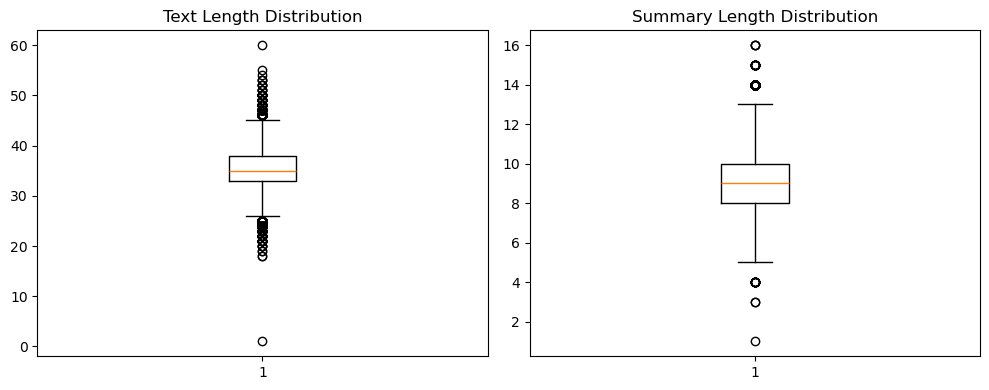

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

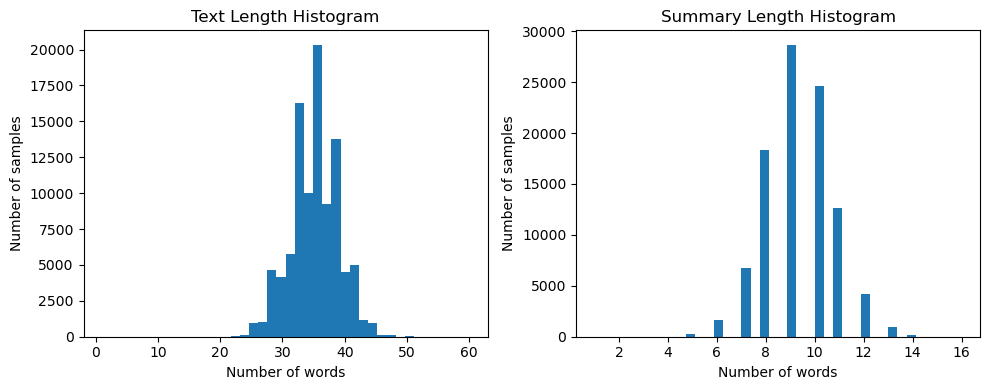

In [14]:
import matplotlib.pyplot as plt

# 각 샘플의 단어 수 계산
text_len = [len(s.split()) for s in data['text']]
summary_len = [len(s.split()) for s in data['summary']]

# 길이 통계 출력
print('Min text length   :', np.min(text_len))
print('Max text length   :', np.max(text_len))
print('Mean text length  :', np.mean(text_len))
print()
print('Min summary length :', np.min(summary_len))
print('Max summary length :', np.max(summary_len))
print('Mean summary length:', np.mean(summary_len))

# 박스플롯으로 길이 분포 시각화
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.boxplot(text_len)
plt.title('Text Length Distribution')
plt.subplot(1, 2, 2)
plt.boxplot(summary_len)
plt.title('Summary Length Distribution')
plt.tight_layout()
plt.show()

# 히스토그램으로 분포 확인
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(text_len, bins=40)
plt.title('Text Length Histogram')
plt.xlabel('Number of words')
plt.ylabel('Number of samples')
plt.subplot(1, 2, 2)
plt.hist(summary_len, bins=40)
plt.title('Summary Length Histogram')
plt.xlabel('Number of words')
plt.ylabel('Number of samples')
plt.tight_layout()
plt.show()

In [15]:
# ----------------------------------------------------------------
# 최대 길이 설정
# text_max_len   : 본문 평균(35)과 최대(60) 사이 값으로 설정
#                  50 이하인 샘플이 전체의 대부분을 차지할 것으로 예상
# summary_max_len: 요약 평균(9)보다 넉넉하게 설정
#                  최대(16)에 가깝게 13으로 설정해 핵심 단어 손실 최소화
# ----------------------------------------------------------------
text_max_len = 50
summary_max_len = 13

def below_threshold_len(max_len, data_column):
    # 전체 샘플 중 max_len 이하인 샘플의 비율 계산
    cnt = sum(1 for s in data_column if len(s.split()) <= max_len)
    print(f'전체 샘플 중 길이가 {max_len} 이하인 샘플의 비율: {cnt / len(data_column) * 100:.2f}%')

below_threshold_len(text_max_len, data['text'])
below_threshold_len(summary_max_len, data['summary'])

전체 샘플 중 길이가 50 이하인 샘플의 비율: 99.99%
전체 샘플 중 길이가 13 이하인 샘플의 비율: 99.82%


In [16]:
# ----------------------------------------------------------------
# 최대 길이 초과 샘플 제거
# 설정한 최대 길이보다 긴 샘플은 잘라내지 않고 아예 제거
# 너무 긴 샘플은 모델 학습에 노이즈가 될 수 있음
# ----------------------------------------------------------------
data = data[data['text'].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data['summary'].apply(lambda x: len(x.split()) <= summary_max_len)]

print('최대 길이 필터링 후 샘플 수:', len(data))

최대 길이 필터링 후 샘플 수: 98170


In [17]:
# ----------------------------------------------------------------
# 디코더 입력/타겟 생성
# seq2seq 모델은 디코더에 두 가지 데이터가 필요
# decoder_input : 시작 토큰(sostoken) + 요약문
#                 → 디코더가 다음 단어를 예측할 때 현재 단어로 사용
# decoder_target: 요약문 + 종료 토큰(eostoken)
#                 → 디코더가 예측해야 할 정답 레이블
#
# 예) 요약문: "good product worth buying"
#     decoder_input : "sostoken good product worth buying"
#     decoder_target: "good product worth buying eostoken"
# ----------------------------------------------------------------
data['decoder_input'] = data['summary'].apply(lambda x: 'sostoken ' + x)
data['decoder_target'] = data['summary'].apply(lambda x: x + ' eostoken')

print('샘플 확인:')
print('원문    :', data['text'].iloc[0])
print('요약    :', data['summary'].iloc[0])
print('디코더입력:', data['decoder_input'].iloc[0])
print('디코더타겟:', data['decoder_target'].iloc[0])

샘플 확인:
원문    : saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers
요약    : upgrad learner switches to career in ml al with salary hike
디코더입력: sostoken upgrad learner switches to career in ml al with salary hike
디코더타겟: upgrad learner switches to career in ml al with salary hike eostoken


In [18]:
# 정수 인코딩
from collections import Counter

# ----------------------------------------------------------------
# 훈련/테스트 데이터 분리
# 정수 인코딩은 반드시 훈련 데이터 기준으로만 만들어야 함
# 테스트 데이터 정보가 단어장에 포함되면 data leakage 발생
# ----------------------------------------------------------------
encoder_input = np.array(data['text'])
decoder_input = np.array(data['decoder_input'])
decoder_target = np.array(data['decoder_target'])

# 인덱스를 랜덤하게 섞어서 훈련/테스트 분리
indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)

encoder_input  = encoder_input[indices]
decoder_input  = decoder_input[indices]
decoder_target = decoder_target[indices]

# 전체 데이터의 80%는 훈련, 20%는 테스트
n_of_val = int(len(encoder_input) * 0.2)

encoder_input_train  = encoder_input[:-n_of_val]
decoder_input_train  = decoder_input[:-n_of_val]
decoder_target_train = decoder_target[:-n_of_val]

encoder_input_test  = encoder_input[-n_of_val:]
decoder_input_test  = decoder_input[-n_of_val:]
decoder_target_test = decoder_target[-n_of_val:]

print('훈련 데이터 수:', len(encoder_input_train))
print('테스트 데이터 수:', len(encoder_input_test))

훈련 데이터 수: 78536
테스트 데이터 수: 19634


In [19]:
# ----------------------------------------------------------------
# 단어장(vocabulary) 구축
# 훈련 데이터에서만 단어 빈도를 계산해서 단어장 생성
# threshold 미만으로 등장한 희귀 단어는 <UNK>로 처리
# ----------------------------------------------------------------
def build_vocab(texts, vocab_size):
    # 특수 토큰: PAD(패딩), UNK(미등록 단어)
    vocab = {'<PAD>': 0, '<UNK>': 1}
    word_counter = Counter()

    for text in texts:
        word_counter.update(text.split())

    # 빈도 높은 순서대로 vocab_size개만 선택
    for word, _ in word_counter.most_common(vocab_size - 2):
        vocab[word] = len(vocab)

    return vocab

# 인코더(본문) 단어장: 8000개
# 디코더(요약) 단어장: 2000개 (요약문 어휘가 더 적음)
src_vocab_size = 8000
tar_vocab_size = 2000

src_vocab = build_vocab(encoder_input_train, src_vocab_size)
tar_vocab = build_vocab(
    list(decoder_input_train) + list(decoder_target_train), tar_vocab_size
)

print('인코더 단어장 크기:', len(src_vocab))
print('디코더 단어장 크기:', len(tar_vocab))

인코더 단어장 크기: 8000
디코더 단어장 크기: 2000


In [20]:
# ----------------------------------------------------------------
# 텍스트 → 정수 시퀀스 변환
# 각 단어를 단어장의 인덱스 번호로 변환
# 단어장에 없는 단어는 <UNK>(인덱스 1)로 대체
# ----------------------------------------------------------------
def text_to_sequence(texts, vocab):
    sequences = []
    for text in texts:
        sequence = [vocab.get(word, vocab['<UNK>']) for word in text.split()]
        sequences.append(sequence)
    return sequences

encoder_input_train_seq  = text_to_sequence(encoder_input_train, src_vocab)
encoder_input_test_seq   = text_to_sequence(encoder_input_test, src_vocab)
decoder_input_train_seq  = text_to_sequence(decoder_input_train, tar_vocab)
decoder_target_train_seq = text_to_sequence(decoder_target_train, tar_vocab)
decoder_input_test_seq   = text_to_sequence(decoder_input_test, tar_vocab)
decoder_target_test_seq  = text_to_sequence(decoder_target_test, tar_vocab)

print('정수 인코딩 완료')
print('인코더 입력 샘플:', encoder_input_train_seq[0])
print('디코더 입력 샘플:', decoder_input_train_seq[0])

정수 인코딩 완료
인코더 입력 샘플: [6640, 59, 995, 311, 6319, 4, 14, 413, 1060, 170, 806, 79, 1, 6320, 136, 1191, 145, 6640, 220, 30, 90, 202, 329, 24, 130, 13, 1, 6257, 6640, 4166, 2449, 314, 173, 125]
디코더 입력 샘플: [2, 1, 604, 1, 508, 5, 56, 1]


In [21]:
# ----------------------------------------------------------------
# 패딩(Padding)
# 모든 시퀀스의 길이를 동일하게 맞춰야 배치 학습이 가능
# 짧은 시퀀스는 0(PAD 토큰)으로 채우고, 긴 시퀀스는 잘라냄
# ----------------------------------------------------------------
from torch.nn.utils.rnn import pad_sequence

def pad_sequences(sequences, maxlen, padding_value=0):
    tensors = [torch.tensor(seq, dtype=torch.long) for seq in sequences]
    padded  = pad_sequence(tensors, batch_first=True, padding_value=padding_value)
    return padded[:, :maxlen]  # maxlen 초과분 제거

encoder_input_train  = pad_sequences(encoder_input_train_seq, text_max_len)
encoder_input_test   = pad_sequences(encoder_input_test_seq, text_max_len)
decoder_input_train  = pad_sequences(decoder_input_train_seq, summary_max_len)
decoder_target_train = pad_sequences(decoder_target_train_seq, summary_max_len)
decoder_input_test   = pad_sequences(decoder_input_test_seq, summary_max_len)
decoder_target_test  = pad_sequences(decoder_target_test_seq, summary_max_len)

print('패딩 완료')
print('인코더 입력 shape:', encoder_input_train.shape)
print('디코더 입력 shape:', decoder_input_train.shape)
print('디코더 타겟 shape:', decoder_target_train.shape)

패딩 완료
인코더 입력 shape: torch.Size([78536, 50])
디코더 입력 shape: torch.Size([78536, 13])
디코더 타겟 shape: torch.Size([78536, 13])


### 3. 어텐션 메커니즘 사용하기

In [22]:
import torch.nn as nn
import torch.nn.functional as F

embedding_dim = 128  # 단어를 몇 차원 벡터로 표현할지
hidden_size   = 256  # LSTM 은닉 상태 크기

# ----------------------------------------------------------------
# 인코더(Encoder)
# 입력 문장(본문)을 받아서 문맥 정보를 압축하는 역할
# 각 단어를 임베딩 벡터로 변환 후 LSTM으로 순서대로 처리
# 최종적으로 hidden, cell 상태를 디코더에 전달
# ----------------------------------------------------------------
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super(Encoder, self).__init__()
        # Embedding: 정수 인덱스 → 밀집 벡터 변환
        # vocab_size개의 단어를 각각 embedding_dim 차원 벡터로 표현
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # LSTM: 시퀀스를 순서대로 처리하며 문맥 정보 학습
        # num_layers=3: LSTM을 3층으로 쌓아 더 복잡한 패턴 학습
        # dropout=0.4 : 과적합 방지를 위해 40% 뉴런을 랜덤하게 비활성화
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size,
            num_layers=num_layers, dropout=dropout, batch_first=True
        )

    def forward(self, x):
        embedded = self.embedding(x)                    # (batch, seq_len, embedding_dim)
        output, (hidden, cell) = self.lstm(embedded)    # output: 모든 시점의 은닉 상태
        return output, hidden, cell                     # output은 어텐션에서 사용

encoder = Encoder(src_vocab_size, embedding_dim, hidden_size)
print('인코더 설계 완료')
print(encoder)

인코더 설계 완료
Encoder(
  (embedding): Embedding(8000, 128)
  (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
)


In [23]:
# ----------------------------------------------------------------
# 디코더(Decoder)
# 인코더의 hidden, cell 상태를 초기값으로 받아
# 한 단어씩 순서대로 요약문을 생성하는 역할
# ----------------------------------------------------------------
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size,
            num_layers=num_layers, dropout=dropout, batch_first=True
        )

    def forward(self, x, hidden, cell):
        embedded = self.embedding(x)                            # (batch, seq_len, embedding_dim)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # 인코더 상태를 초기값으로 사용
        return output, hidden, cell

decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size)
print('디코더 설계 완료')
print(decoder)

디코더 설계 완료
Decoder(
  (embedding): Embedding(2000, 128)
  (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
)


In [24]:
# ----------------------------------------------------------------
# 어텐션(Attention)
# 디코더가 현재 단어를 생성할 때 인코더의 어느 부분에
# 집중해야 할지 가중치를 계산하는 메커니즘
#
# [작동 원리]
# 1. 디코더 출력과 인코더 출력을 내적(dot product)
# 2. softmax로 정규화 → 각 인코더 시점의 중요도(0~1)
# 3. 중요도에 따라 인코더 출력을 가중합 → context vector
# ----------------------------------------------------------------
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()

    def forward(self, decoder_output, encoder_outputs):
        # decoder_output : (batch, decoder_seq, hidden)
        # encoder_outputs: (batch, encoder_seq, hidden)

        # 내적으로 유사도 계산
        # (batch, decoder_seq, hidden) x (batch, hidden, encoder_seq)
        # → (batch, decoder_seq, encoder_seq)
        attn_weights = torch.bmm(decoder_output, encoder_outputs.transpose(1, 2))

        # softmax: 각 인코더 시점의 중요도를 확률값으로 변환
        attn_weights = F.softmax(attn_weights, dim=-1)

        # 중요도에 따라 인코더 출력을 가중합 → context vector
        # (batch, decoder_seq, encoder_seq) x (batch, encoder_seq, hidden)
        # → (batch, decoder_seq, hidden)
        context = torch.bmm(attn_weights, encoder_outputs)

        return context

print('어텐션 설계 완료')

어텐션 설계 완료


In [25]:
# ----------------------------------------------------------------
# Seq2Seq with Attention 전체 모델
# 인코더 → 디코더 → 어텐션 → 출력층을 하나로 합친 최종 모델
# ----------------------------------------------------------------
class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, vocab_size, hidden_size):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder     = encoder
        self.decoder     = decoder
        self.attention   = Attention(hidden_size)

        # concat: 디코더 출력(hidden)과 context vector를 합친 후
        # 다시 hidden_size로 축소
        # hidden_size * 2 → hidden_size
        self.concat      = nn.Linear(hidden_size * 2, hidden_size)

        # 최종 출력층: hidden → 단어장 크기
        # 각 단어의 확률값 출력
        self.output_layer = nn.Linear(hidden_size, vocab_size)

    def forward(self, encoder_input, decoder_input):
        # 1. 인코더 실행: 본문 전체를 처리해 문맥 정보 압축
        encoder_outputs, hidden, cell = self.encoder(encoder_input)

        # 2. 디코더 실행: 인코더의 hidden, cell을 초기 상태로 사용
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        # 3. 어텐션 적용: 디코더가 인코더의 어느 부분에 집중할지 계산
        context = self.attention(decoder_outputs, encoder_outputs)

        # 4. 디코더 출력 + context vector 결합
        # torch.cat으로 두 벡터를 이어붙인 후 Linear로 차원 축소
        combined = torch.cat((decoder_outputs, context), dim=-1)
        combined = torch.tanh(self.concat(combined))  # tanh로 비선형성 추가

        # 5. 최종 출력: 각 시점에서 다음 단어의 확률 분포
        output = self.output_layer(combined)
        return output

# 모델 생성
model = Seq2SeqWithAttention(encoder, decoder, tar_vocab_size, hidden_size)
print('Seq2Seq + Attention 모델 생성 완료')
print(model)

Seq2Seq + Attention 모델 생성 완료
Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(8000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(2000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=2000, bias=True)
)


In [26]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'학습 장치: {device}')
model.to(device)

# ----------------------------------------------------------------
# 하이퍼파라미터 설정
# batch_size : 한 번에 학습할 샘플 수
#              클수록 학습 빠르지만 메모리 많이 사용
# epochs     : 전체 데이터를 몇 번 반복 학습할지
# patience   : EarlyStopping 기준
#              validation loss가 patience번 연속 개선 안 되면 조기 종료
# ----------------------------------------------------------------
batch_size    = 256
epochs        = 50
learning_rate = 0.001
patience      = 3  # 오늘 실습(patience=2)보다 1 늘려 학습 기회 확보

# 손실 함수: CrossEntropyLoss
# ignore_index=0: PAD 토큰(인덱스 0)은 손실 계산에서 제외
# PAD는 의미 없는 패딩이므로 학습 대상에서 빼야 함
criterion = nn.CrossEntropyLoss(ignore_index=0)

# AdamW: Adam 옵티마이저에 weight decay(L2 정규화)를 추가한 버전
# 과적합 방지 효과가 Adam보다 뛰어남
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# DataLoader: 데이터를 배치 단위로 자동으로 나눠줌
# shuffle=True: 매 에폭마다 데이터 순서를 섞어 과적합 방지
train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
test_dataset  = TensorDataset(encoder_input_test, decoder_input_test, decoder_target_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f'훈련 배치 수: {len(train_loader)}')
print(f'테스트 배치 수: {len(test_loader)}')

학습 장치: cuda
훈련 배치 수: 307
테스트 배치 수: 77


In [27]:
train_losses = []
val_losses   = []

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    best_val_loss    = float('inf')
    early_stop_count = 0

    for epoch in range(epochs):
        # ── 훈련 단계 ──────────────────────────────────────────
        model.train()
        total_loss = 0

        for enc_input, dec_input, target in train_loader:
            optimizer.zero_grad()  # 이전 배치의 gradient 초기화

            enc_input = enc_input.to(device).long()
            dec_input = dec_input.to(device).long()
            target    = target.to(device).long()

            # 순전파
            output = model(enc_input, dec_input)

            # output: (batch, seq_len, vocab_size) → (batch*seq_len, vocab_size)
            # target: (batch, seq_len)              → (batch*seq_len)
            # CrossEntropyLoss는 2D 입력을 요구하므로 reshape 필요
            output = output.view(-1, output.shape[-1])
            target = target.view(-1)

            loss = criterion(output, target)
            loss.backward()   # 역전파: gradient 계산
            optimizer.step()  # 가중치 업데이트
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ── 검증 단계 ──────────────────────────────────────────
        model.eval()
        total_val_loss = 0

        with torch.no_grad():  # 검증 시에는 gradient 계산 불필요
            for enc_input, dec_input, target in test_loader:
                enc_input = enc_input.to(device).long()
                dec_input = dec_input.to(device).long()
                target    = target.to(device).long()

                output = model(enc_input, dec_input)
                output = output.view(-1, output.shape[-1])
                target = target.view(-1)

                total_val_loss += criterion(output, target).item()

        avg_val_loss = total_val_loss / len(test_loader)
        val_losses.append(avg_val_loss)

        print(f'Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

        # ── EarlyStopping ──────────────────────────────────────
        # val loss가 개선되면 카운터 초기화, 아니면 카운터 증가
        # patience번 연속 개선 없으면 학습 조기 종료
        if avg_val_loss < best_val_loss:
            best_val_loss    = avg_val_loss
            early_stop_count = 0
            torch.save(model.state_dict(), 'best_model.pt')  # 최적 모델 저장
            print(f'            → Val Loss 개선: {best_val_loss:.4f} (모델 저장)')
        else:
            early_stop_count += 1
            print(f'            → 개선 없음 ({early_stop_count}/{patience})')
            if early_stop_count >= patience:
                print(f'\nEarly Stopping! (Epoch {epoch+1}에서 종료)')
                break

print('train_model 함수 정의 완료')

train_model 함수 정의 완료


In [28]:
%%time
# GPU 환경 권장 (CPU에서는 30분 이상 소요될 수 있음)
train_model(model, train_loader, test_loader, criterion, optimizer, epochs, patience)

Epoch  1/50 | Train Loss: 5.0236 | Val Loss: 4.7806
            → Val Loss 개선: 4.7806 (모델 저장)
Epoch  2/50 | Train Loss: 4.6034 | Val Loss: 4.3840
            → Val Loss 개선: 4.3840 (모델 저장)
Epoch  3/50 | Train Loss: 4.2352 | Val Loss: 4.0469
            → Val Loss 개선: 4.0469 (모델 저장)
Epoch  4/50 | Train Loss: 3.9317 | Val Loss: 3.8086
            → Val Loss 개선: 3.8086 (모델 저장)
Epoch  5/50 | Train Loss: 3.7096 | Val Loss: 3.6385
            → Val Loss 개선: 3.6385 (모델 저장)
Epoch  6/50 | Train Loss: 3.5243 | Val Loss: 3.4894
            → Val Loss 개선: 3.4894 (모델 저장)
Epoch  7/50 | Train Loss: 3.3716 | Val Loss: 3.3812
            → Val Loss 개선: 3.3812 (모델 저장)
Epoch  8/50 | Train Loss: 3.2427 | Val Loss: 3.2967
            → Val Loss 개선: 3.2967 (모델 저장)
Epoch  9/50 | Train Loss: 3.1304 | Val Loss: 3.2320
            → Val Loss 개선: 3.2320 (모델 저장)
Epoch 10/50 | Train Loss: 3.0316 | Val Loss: 3.1801
            → Val Loss 개선: 3.1801 (모델 저장)
Epoch 11/50 | Train Loss: 2.9434 | Val Loss: 3.1384
        

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

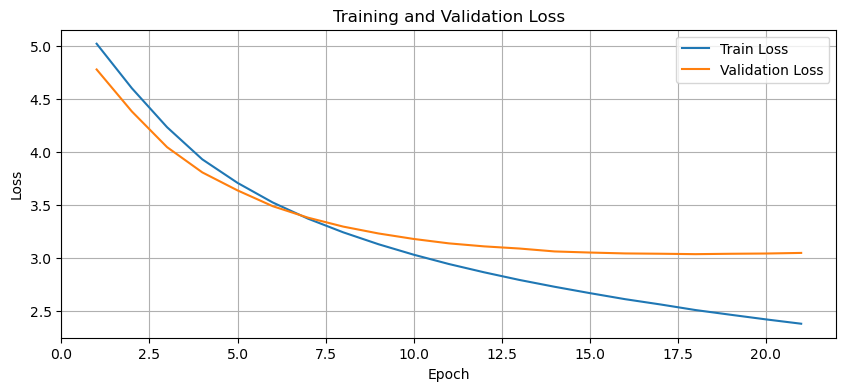

최종 Train Loss    : 2.3797
최종 Val Loss      : 3.0483
최저 Val Loss      : 3.0366 (Epoch 18)


In [29]:
# 훈련/검증 손실 그래프
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

print(f'최종 Train Loss    : {train_losses[-1]:.4f}')
print(f'최종 Val Loss      : {val_losses[-1]:.4f}')
print(f'최저 Val Loss      : {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses))+1})')

1. Train Loss 2.38, Val Loss 3.05로 학습이 진행되면서 손실이 줄어드는 형상 확인
2. Epoch 18에서 최저 Val Loss 달성 후 3번 연속 개선이 없어 Epoch 21에서 조기 종료

### 4. 실제 결과와 요약문 비교하기

In [30]:
# 인퍼런스를 위한 단어 ↔ 인덱스 변환 딕셔너리 생성
src_index_to_word = {idx: word for word, idx in src_vocab.items()}  # 인덱스 → 단어 (본문)
tar_word_to_index = tar_vocab                                        # 단어 → 인덱스 (요약)
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()}  # 인덱스 → 단어 (요약)

print('변환 딕셔너리 생성 완료')

변환 딕셔너리 생성 완료


In [31]:
def decode_sequence(input_seq, encoder, decoder_model, tar_word_to_index, tar_index_to_word, summary_max_len, device):
    encoder.eval()
    decoder_model.eval()

    with torch.no_grad():
        # 1. 인코더 실행: 입력 본문을 문맥 벡터로 압축
        input_seq = input_seq.to(device)
        encoder_outputs, hidden, cell = encoder(input_seq)

        # 2. 디코더 시작 토큰(sostoken) 준비
        # sostoken 인덱스를 찾아서 디코더 첫 입력으로 사용
        target_seq = torch.tensor(
            [[tar_word_to_index['sostoken']]], dtype=torch.long, device=device
        )

        decoded_sentence = ''
        stop_condition   = False

        while not stop_condition:
            # 3. 디코더 한 스텝 실행
            decoder_output, hidden, cell = decoder_model.decoder(target_seq, hidden, cell)

            # 4. 어텐션 적용
            context = decoder_model.attention(decoder_output, encoder_outputs)

            # 5. 디코더 출력 + context 결합 후 다음 단어 예측
            combined = torch.cat((decoder_output, context), dim=-1)
            combined = torch.tanh(decoder_model.concat(combined))
            output   = decoder_model.output_layer(combined)

            # 6. 가장 높은 확률의 단어 선택
            predicted_idx  = torch.argmax(output[0, -1, :]).item()
            predicted_word = tar_index_to_word.get(predicted_idx, '<UNK>')

            # 7. eostoken이 나오거나 최대 길이 초과 시 종료
            if predicted_word == 'eostoken' or len(decoded_sentence.split()) >= summary_max_len - 1:
                stop_condition = True
            else:
                decoded_sentence += ' ' + predicted_word

            # 8. 다음 스텝 입력으로 현재 예측 단어 사용
            target_seq = torch.tensor([[predicted_idx]], dtype=torch.long, device=device)

    return decoded_sentence.strip()

print('decode_sequence 함수 정의 완료')

decode_sequence 함수 정의 완료


In [32]:
# 정수 시퀀스 → 텍스트 변환 함수
def seq2text(input_seq):
    # PAD(0) 토큰을 제외하고 단어로 변환
    return ' '.join(
        src_index_to_word.get(int(idx), '<UNK>')
        for idx in input_seq if int(idx) != 0
    )

def seq2summary(input_seq):
    # PAD(0), sostoken, eostoken 제외하고 단어로 변환
    return ' '.join(
        tar_index_to_word.get(int(idx), '<UNK>')
        for idx in input_seq
        if int(idx) != 0
        and int(idx) != tar_word_to_index.get('sostoken')
        and int(idx) != tar_word_to_index.get('eostoken')
    )

print('seq2text, seq2summary 함수 정의 완료')

seq2text, seq2summary 함수 정의 완료


In [33]:
# 테스트 데이터 50~60번 샘플로 결과 비교
print('=' * 70)
for i in range(50, 60):
    input_seq = encoder_input_test[i].unsqueeze(0).to(device)  # (1, seq_len)

    print(f'[샘플 {i}]')
    print('원문    :', seq2text(encoder_input_test[i]))
    print('실제 요약:', seq2summary(decoder_input_test[i]))
    print('예측 요약:', decode_sequence(
        input_seq, encoder, model, tar_word_to_index,
        tar_index_to_word, summary_max_len, device
    ))
    print('-' * 70)

[샘플 50]
원문    : two brothers began technology startup <UNK> <UNK> parents house america ryan <UNK> smith become billionaires selling startup <UNK> billion backed accel sequoia <UNK> last valued billion founded <UNK> makes customer survey software used companies like microsoft general electric
실제 요약: brothers sell their startup to <UNK> for bn become <UNK>
예측 요약: two brothers <UNK> startup <UNK> <UNK> to <UNK> in china
----------------------------------------------------------------------
[샘플 51]
원문    : trolling actor salman khan tweeted message <UNK> former pm atal bihari vajpayee five days demise twitter user wrote tiger <UNK> tha referring character tiger franchise another user wrote internet <UNK> use <UNK> hain comment read bhai <UNK> newspaper <UNK> hai
실제 요약: tiger so <UNK> <UNK> salman trolled for late tweet on vajpayee death
예측 요약: <UNK> <UNK> hai salman on vajpayee <UNK> birthday
----------------------------------------------------------------------
[샘플 52]
원문    : assistant 

### 5. Summa을 이용하여 추출적 요약해보기

In [34]:
from summa.summarizer import summarize

# 테스트 샘플 50~59번의 원문을 추출적 요약으로 요약
print('=' * 70)
for i in range(50, 60):
    # 원문 복원 (전처리 전 원본 텍스트 사용)
    original_text = seq2text(encoder_input_test[i])

    # summa TextRank 추출적 요약
    # ratio=0.3: 원문의 30% 분량으로 요약
    extractive_summary = summarize(original_text, ratio=0.3)

    # 추출적 요약 결과가 없으면 첫 문장 사용
    if not extractive_summary:
        extractive_summary = original_text.split('.')[0]

    print(f'[샘플 {i}]')
    print('원문         :', original_text[:80] + '...')
    print('실제 요약    :', seq2summary(decoder_input_test[i]))
    print('추상적 요약  :', decode_sequence(
        encoder_input_test[i].unsqueeze(0).to(device), encoder, model,
        tar_word_to_index, tar_index_to_word, summary_max_len, device
    ))
    print('추출적 요약  :', extractive_summary[:100] if extractive_summary else '(결과 없음)')
    print('-' * 70)

[샘플 50]
원문         : two brothers began technology startup <UNK> <UNK> parents house america ryan <UN...
실제 요약    : brothers sell their startup to <UNK> for bn become <UNK>
추상적 요약  : two brothers <UNK> startup <UNK> <UNK> to <UNK> in china
추출적 요약  : two brothers began technology startup <UNK> <UNK> parents house america ryan <UNK> smith become bill
----------------------------------------------------------------------
[샘플 51]
원문         : trolling actor salman khan tweeted message <UNK> former pm atal bihari vajpayee ...
실제 요약    : tiger so <UNK> <UNK> salman trolled for late tweet on vajpayee death
추상적 요약  : <UNK> <UNK> hai salman on vajpayee <UNK> birthday
추출적 요약  : trolling actor salman khan tweeted message <UNK> former pm atal bihari vajpayee five days demise twi
----------------------------------------------------------------------
[샘플 52]
원문         : assistant sub inspector hasan telangana <UNK> <UNK> district suspended tuesday a...
실제 요약    : telangana cop suspended over <UNK> 

In [37]:
# ================================================================
# 스텝4 & 스텝5: 추상적 요약 vs 추출적 요약 비교 분석표
# 평가 기준 1: 문법 완성도 (자연스러운 문장인가?)
# 평가 기준 2: 핵심 단어 포함 (실제 요약의 핵심 단어가 포함됐는가?)
# ================================================================

comparison = [
    {
        'sample': 50,
        'actual':      'brothers sell their startup to <UNK> for bn become <UNK>',
        'abstractive': 'two brothers <UNK> startup <UNK> to <UNK> in china',
        'extractive':  'two brothers began technology startup parents house america ryan smith become billionaires',
        'grammar_abs': '△',  # 문장 구조는 있으나 UNK로 의미 손실
        'grammar_ext': '✕',  # 원문 그대로라 문장이 끊김
        'keyword_abs': '△',  # brothers, startup 포함
        'keyword_ext': '○',  # brothers, startup, billionaires 포함
    },
    {
        'sample': 52,
        'actual':      'telangana cop suspended over <UNK> from female home guard',
        'abstractive': 'telangana man suspended for <UNK> female teacher',
        'extractive':  'assistant sub inspector hasan telangana district suspended tuesday allegedly receiving',
        'grammar_abs': '○',  # 자연스러운 문장 구조
        'grammar_ext': '△',  # 원문 나열로 어색
        'keyword_abs': '○',  # telangana, suspended, female 포함
        'keyword_ext': '○',  # telangana, suspended 포함
    },
    {
        'sample': 56,
        'actual':      'women use metoo on social media to <UNK> sexual assault',
        'abstractive': 'twitter reacts to sexual assault assault <UNK> <UNK>',
        'extractive':  'following actor tweet urging women share sexual harassment assault experiences thousands',
        'grammar_abs': '△',  # assault 중복, UNK 존재
        'grammar_ext': '✕',  # 문장 구조 없이 단어 나열
        'keyword_abs': '○',  # sexual assault 포함
        'keyword_ext': '○',  # women, sexual, assault 포함
    },
    {
        'sample': 57,
        'actual':      'uber to make flying <UNK> in paris with new <UNK> centre',
        'abstractive': 'uber to open <UNK> cars in <UNK> for crore',
        'extractive':  'uber announced open research centre paris flying cars developed uber first research hub',
        'grammar_abs': '○',  # 가장 자연스러운 문장
        'grammar_ext': '△',  # uber 중복, 나열식
        'keyword_abs': '○',  # uber, cars 포함
        'keyword_ext': '○',  # uber, centre, paris, flying, cars 포함
    },
    {
        'sample': 59,
        'actual':      '<UNK> to play olympic gold <UNK> in biopic',
        'abstractive': 'anil kapoor shares <UNK> with <UNK>',
        'extractive':  'anil kapoor son actor kapoor play olympic gold medallist upcoming biopic retired',
        'grammar_abs': '△',  # 핵심 내용 누락
        'grammar_ext': '△',  # 나열식이지만 핵심 단어 포함
        'keyword_abs': '✕',  # olympic, biopic 누락
        'keyword_ext': '○',  # olympic, gold, biopic 포함
    },
]

# 표 출력
print('=' * 90)
print('샘플  | 구분       | 문법완성도 | 핵심단어 | 요약 결과')
print('=' * 90)

for row in comparison:
    print(f"[Sample {row['sample']}]")
    print(f"  실제 요약  |            |          | {row['actual']}")
    print(f"  추상적요약 | {row['grammar_abs']}          | {row['keyword_abs']}        | {row['abstractive']}")
    print(f"  추출적요약 | {row['grammar_ext']}          | {row['keyword_ext']}        | {row['extractive'][:60]}...")
    print('-' * 90)



샘플  | 구분       | 문법완성도 | 핵심단어 | 요약 결과
[Sample 50]
  실제 요약  |            |          | brothers sell their startup to <UNK> for bn become <UNK>
  추상적요약 | △          | △        | two brothers <UNK> startup <UNK> to <UNK> in china
  추출적요약 | ✕          | ○        | two brothers began technology startup parents house america ...
------------------------------------------------------------------------------------------
[Sample 52]
  실제 요약  |            |          | telangana cop suspended over <UNK> from female home guard
  추상적요약 | ○          | ○        | telangana man suspended for <UNK> female teacher
  추출적요약 | △          | ○        | assistant sub inspector hasan telangana district suspended t...
------------------------------------------------------------------------------------------
[Sample 56]
  실제 요약  |            |          | women use metoo on social media to <UNK> sexual assault
  추상적요약 | △          | ○        | twitter reacts to sexual assault assault <UNK> <UNK>
  추출적요약 | ✕      

In [38]:
from IPython.display import display, HTML

html = """
<style>
  .wrap { font-family: sans-serif; padding: 1rem 0; }
  table { width: 100%; border-collapse: collapse; font-size: 13px; table-layout: fixed; }
  th { background: #f5f5f5; color: #666; font-weight: 600; padding: 10px 12px;
       text-align: center; border: 1px solid #e0e0e0; }
  td { padding: 9px 12px; border: 1px solid #e0e0e0; vertical-align: middle; }
  .sample-col { width: 60px;  text-align: center; font-weight: 600; color: #888; }
  .type-col   { width: 80px;  text-align: center; }
  .score-col  { width: 80px;  text-align: center; }
  .text-col   { text-align: left; font-size: 12px; color: #555; line-height: 1.5; }
  .badge { display: inline-block; font-size: 11px; font-weight: 600;
           padding: 2px 8px; border-radius: 20px; }
  .good     { background: #E1F5EE; color: #085041; }
  .mid      { background: #FAEEDA; color: #633806; }
  .bad      { background: #FCEBEB; color: #791F1F; }
  .abs-badge { background: #EEEDFE; color: #3C3489; }
  .ext-badge { background: #E1F5EE; color: #085041; }
  .section-header td { background: #fafafa; font-weight: 600;
                       font-size: 12px; color: #999; padding: 6px 12px; }
  .legend { display: flex; gap: 12px; margin-top: 12px;
            font-size: 12px; color: #666; align-items: center; }
  .conclusion { margin-top: 16px; background: #fafafa;
                border-radius: 8px; padding: 12px 16px; }
  .con-row { display: flex; gap: 8px; align-items: flex-start;
             font-size: 12px; color: #666; margin-bottom: 6px; line-height: 1.6; }
  .con-label { font-weight: 600; min-width: 70px; color: #333; }
</style>

<div class="wrap">
  <table>
    <thead>
      <tr>
        <th class="sample-col">샘플</th>
        <th class="type-col">방법</th>
        <th class="score-col">문법 완성도</th>
        <th class="score-col">핵심 단어</th>
        <th class="text-col">요약 결과</th>
      </tr>
    </thead>
    <tbody>
      <tr class="section-header"><td colspan="5">Sample 50 — 스타트업 형제 이야기</td></tr>
      <tr>
        <td class="sample-col" rowspan="2">50</td>
        <td class="type-col"><span class="badge abs-badge">추상적</span></td>
        <td class="score-col"><span class="badge mid">△ 보통</span></td>
        <td class="score-col"><span class="badge mid">△ 보통</span></td>
        <td class="text-col">two brothers &lt;UNK&gt; startup &lt;UNK&gt; to &lt;UNK&gt; in china</td>
      </tr>
      <tr>
        <td class="type-col"><span class="badge ext-badge">추출적</span></td>
        <td class="score-col"><span class="badge bad">✕ 미흡</span></td>
        <td class="score-col"><span class="badge good">○ 우수</span></td>
        <td class="text-col">two brothers began technology startup parents house america ryan smith become billionaires...</td>
      </tr>

      <tr class="section-header"><td colspan="5">Sample 52 — 경찰관 정직 처분</td></tr>
      <tr>
        <td class="sample-col" rowspan="2">52</td>
        <td class="type-col"><span class="badge abs-badge">추상적</span></td>
        <td class="score-col"><span class="badge good">○ 우수</span></td>
        <td class="score-col"><span class="badge good">○ 우수</span></td>
        <td class="text-col">telangana man suspended for &lt;UNK&gt; female teacher</td>
      </tr>
      <tr>
        <td class="type-col"><span class="badge ext-badge">추출적</span></td>
        <td class="score-col"><span class="badge mid">△ 보통</span></td>
        <td class="score-col"><span class="badge good">○ 우수</span></td>
        <td class="text-col">assistant sub inspector hasan telangana district suspended tuesday allegedly receiving...</td>
      </tr>

      <tr class="section-header"><td colspan="5">Sample 56 — MeToo 운동</td></tr>
      <tr>
        <td class="sample-col" rowspan="2">56</td>
        <td class="type-col"><span class="badge abs-badge">추상적</span></td>
        <td class="score-col"><span class="badge mid">△ 보통</span></td>
        <td class="score-col"><span class="badge good">○ 우수</span></td>
        <td class="text-col">twitter reacts to sexual assault assault &lt;UNK&gt; &lt;UNK&gt;</td>
      </tr>
      <tr>
        <td class="type-col"><span class="badge ext-badge">추출적</span></td>
        <td class="score-col"><span class="badge bad">✕ 미흡</span></td>
        <td class="score-col"><span class="badge good">○ 우수</span></td>
        <td class="text-col">following actor tweet urging women share sexual harassment assault experiences thousands...</td>
      </tr>

      <tr class="section-header"><td colspan="5">Sample 57 — Uber 플라잉카 연구소</td></tr>
      <tr>
        <td class="sample-col" rowspan="2">57</td>
        <td class="type-col"><span class="badge abs-badge">추상적</span></td>
        <td class="score-col"><span class="badge good">○ 우수</span></td>
        <td class="score-col"><span class="badge good">○ 우수</span></td>
        <td class="text-col">uber to open &lt;UNK&gt; cars in &lt;UNK&gt; for crore</td>
      </tr>
      <tr>
        <td class="type-col"><span class="badge ext-badge">추출적</span></td>
        <td class="score-col"><span class="badge mid">△ 보통</span></td>
        <td class="score-col"><span class="badge good">○ 우수</span></td>
        <td class="text-col">uber announced open research centre paris flying cars developed uber first research hub...</td>
      </tr>

      <tr class="section-header"><td colspan="5">Sample 59 — 아닐 카푸어 전기 영화</td></tr>
      <tr>
        <td class="sample-col" rowspan="2">59</td>
        <td class="type-col"><span class="badge abs-badge">추상적</span></td>
        <td class="score-col"><span class="badge mid">△ 보통</span></td>
        <td class="score-col"><span class="badge bad">✕ 미흡</span></td>
        <td class="text-col">anil kapoor shares &lt;UNK&gt; with &lt;UNK&gt;</td>
      </tr>
      <tr>
        <td class="type-col"><span class="badge ext-badge">추출적</span></td>
        <td class="score-col"><span class="badge mid">△ 보통</span></td>
        <td class="score-col"><span class="badge good">○ 우수</span></td>
        <td class="text-col">anil kapoor son actor kapoor play olympic gold medallist upcoming biopic retired...</td>
      </tr>
    </tbody>
  </table>

  <div class="legend">
    <span><span class="badge good">○ 우수</span></span>
    <span><span class="badge mid">△ 보통</span></span>
    <span><span class="badge bad">✕ 미흡</span></span>
  </div>

  <div class="conclusion">
    <div class="con-row">
      <span class="con-label">문법 완성도</span>
      <span>추상적 요약이 문장 구조를 갖춰 상대적으로 자연스러우나, UNK 토큰으로 의미 전달이 불완전한 경우 있음</span>
    </div>
    <div class="con-row">
      <span class="con-label">핵심 단어</span>
      <span>추출적 요약이 원문에서 직접 추출하므로 핵심 단어를 대체로 잘 포함하나, 불필요한 단어도 함께 포함됨</span>
    </div>
    <div class="con-row" style="margin-bottom:0">
      <span class="con-label">개선 방향</span>
      <span>단어장 크기 확대 또는 훈련 데이터 증가 시 UNK 토큰 문제 해결 가능</span>
    </div>
  </div>
</div>
"""

display(HTML(html))

### 회고
1. 실험결과
   1) 학습은 총 21에폭에서 earlystopping으로 조기종료 되었음.
   2) 최종 train loss는 2.3797, validation loss는 3.0483으로 약 0.67의 차이를 보였으며 최저 validation loss는 18에폭에서 3.0366을 기록하였음
   3) train loss와 val loss 모두 감소하는 경향을 보여 학습이 정상적으로 진행되었음을 확인할 수 있었음
   4) 다만 train loss와 val loss 사이의 간격이 존재하는 것으로 보아 약간의 과적합이 발생했음도 알 수 있었음.
      
2. 추상적 요약
   1) 잘된 경우(sample 52, 57)
      - sample52에서 추상적 요약은 "telangana man suspended for <UNK> female teacher"를 생성했음.
      - 실제 요약인 "telangana cop suspended over <UNK> from female home guard"와 비교했을 때 telangana, suspended, female 등 핵심 단어를 포함하고 있으며 문장 구조도 자연스러움.
      - sample57에서도 "uber to open cars in for crore"를 생성하여 uber, open, cars 등 주제어를 포함한 완성된 문장 형태를 보였음.
   2) 한계가 드러난 경우(sample 54, 58, 59)
      - Sample 54와 58에서는 예측 요약이 UNK 토큰으로만 구성되어 의미 있는 요약을 생성하지 못했음
      - 이는 해당 샘플의 핵심 단어들이 단어장(vocab_size=2000)에 포함되지 않아 발생한 문제로 분석됨
      - Sample 59에서는 "anil kapoor shares with"를 생성하여 주제인 olympic, biopic 등의 핵심 단어를 누락했음
   3) UNK 토큰 문제
      - 전체 예측 결과에서 UNK 토큰이 빈번하게 등장
      - 이는 디코더 단어장 크기를 2000으로 제한했기 때문으로, 뉴스 기사 특성상 고유명사(인명, 지명, 기관명)가 많아 단어장에 포함되지 못한 단어가 많았음
      - 단어장 크기를 5000 이상으로 늘리거나 더 많은 훈련 데이터를 사용하면 개선 가능할 것으로 판단됨.
        
3. 추출적 요약
   1) 핵심 단어 포함 측면
      - 5개 샘플 모두에서 핵심 단어를 포함한 결과를 보임
      - Sample 50에서는 brothers, startup, billionaires를, Sample 57에서는 uber, research, centre, paris, flying, cars를 모두 포함하여 원문의 핵심 내용을 잘 보임.
      - 추출적 요약은 원문 문장을 그대로 가져오는 특성상 단어 누락이 없다는 강점이 있음.
   2) 문법 완성도 측면
      - 반면 문법 완성도 측면에서는 대부분 보통(△) 또는 미흡(✕) 수준을 보였음.
      - Sample 50과 56에서는 원문 단어를 나열하는 형태로 완결된 문장을 구성하지 못했음.
      - 특히 뉴스 기사 본문이 이미 전처리(불용어 제거, 특수문자 제거)를 거친 상태였기 때문에 추출된 문장이 더욱 어색하게 느껴졌음.

4. 향후 개선
   1) 추상적 요약의 UNK 토큰 문제
  
5. 소감 : 역시나 어려웠고 학습을 진행함에 있어서 너무나 시간이 없고 촉박한 관계로 실제 수업시간에는 개념 파악하는데 많은 시간이 소요되었음. 이후 야간에 나머지 프로젝트를 수행함에 있어서도 많은 한계를 느끼고 있지만
          최대한 LLM을 활용해서 부딪히는 문제를 해결하고 파이썬 언어에 대한 이해도가 낮을지라도 포기하지 말자는 생각으로 버티고 있음. 그나마 LLM의 도움을 많이 받아 프로젝트를 완성하고 있는것이 다행이라고 생각함.
   